# Part 3 Analysis Notebook

This notebook is a **read-only analysis surface** for Week 1 part 3.
It builds on the existing `query_eval` reporting pipeline instead of re-implementing execution logic.

Use it to:
- load the latest `evaluation_results/query_eval/...` run
- inspect aggregate CSV outputs
- compare the 3 modes on correctness and performance
- surface where `minor_optimization` gains speed or loses recall
- generate presentation-ready tables and figures

Do **not** use this notebook to rebuild the query engine.
If you need new experiments, use:
- `python3 -m query_eval.cli run-suite ...`
- or `query_eval.runner.run_suite(...)`

If you need project context first, read:
- `query_eval/README.md`


## 1. Resolve a Results Directory

By default, this notebook loads the newest directory under `evaluation_results/query_eval/`.
If you want to analyze a specific run instead, set `RESULTS_DIR` explicitly in the next cell.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 120)

RESULTS_ROOT = Path('evaluation_results/query_eval')
RESULTS_DIR = None  # Example: Path('evaluation_results/query_eval/20260415_021241_smoke_suite')
EXPORT_FIGURES = False

MODE_ORDER = ['decompressed_text', 'full_decompression', 'minor_optimization']
MODE_LABELS = {
    'decompressed_text': 'Decompressed Text',
    'full_decompression': 'Full Decompression',
    'minor_optimization': 'Minor Optimization',
}
MODE_COLORS = {
    'decompressed_text': '#4C78A8',
    'full_decompression': '#F58518',
    'minor_optimization': '#54A24B',
}


def resolve_results_dir(results_dir: Path | None = None) -> Path:
    if results_dir is not None:
        if not results_dir.exists():
            raise FileNotFoundError(f'Requested results directory does not exist: {results_dir}')
        return results_dir

    if not RESULTS_ROOT.exists():
        raise FileNotFoundError(
            'No evaluation results directory found. Run the suite first with '
            '`python3 -m query_eval.cli run-suite ...`.'
        )

    run_dirs = sorted([path for path in RESULTS_ROOT.iterdir() if path.is_dir()])
    if not run_dirs:
        raise FileNotFoundError(
            'No run directories found under evaluation_results/query_eval/. '
            'Run the suite first.'
        )
    return run_dirs[-1]


def order_modes(frame: pd.DataFrame) -> pd.DataFrame:
    if 'mode_name' not in frame.columns:
        return frame.copy()
    ordered = frame.copy()
    ordered['mode_name'] = pd.Categorical(ordered['mode_name'], categories=MODE_ORDER, ordered=True)
    sort_columns = [column for column in ['dataset_slug', 'query_id', 'mode_name'] if column in ordered.columns]
    if sort_columns:
        ordered = ordered.sort_values(sort_columns).reset_index(drop=True)
    return ordered


def maybe_savefig(fig: plt.Figure, results_dir: Path, stem: str) -> None:
    if not EXPORT_FIGURES:
        return
    export_dir = results_dir / 'part3_figures'
    export_dir.mkdir(parents=True, exist_ok=True)
    output_path = export_dir / f'{stem}.png'
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print(f'Saved figure: {output_path}')


def annotate_bars(ax: plt.Axes, fmt: str = '{:.2f}') -> None:
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height):
            continue
        ax.annotate(
            fmt.format(height),
            (patch.get_x() + patch.get_width() / 2, height),
            ha='center',
            va='bottom',
            fontsize=8,
            xytext=(0, 3),
            textcoords='offset points',
        )


def plot_heatmap(ax: plt.Axes, frame: pd.DataFrame, title: str, cmap: str = 'YlGn', vmin: float = 0.0, vmax: float = 1.0):
    image = ax.imshow(frame.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(len(frame.columns)))
    ax.set_xticklabels(frame.columns, rotation=35, ha='right')
    ax.set_yticks(range(len(frame.index)))
    ax.set_yticklabels(frame.index)

    for row_index in range(frame.shape[0]):
        for column_index in range(frame.shape[1]):
            value = frame.iloc[row_index, column_index]
            if pd.isna(value):
                continue
            text_color = 'white' if value < 0.6 else 'black'
            ax.text(column_index, row_index, f'{value:.2f}', ha='center', va='center', color=text_color, fontsize=9)
    return image


def first_sample(value):
    if isinstance(value, list) and value:
        return value[0]
    return ''


results_dir = resolve_results_dir(RESULTS_DIR)
print(f'Using results directory: {results_dir}')


Using results directory: evaluation_results\query_eval\20260415_021241_smoke_suite


## 2. Load the Run Artifacts

This cell loads:
- `manifest.json`
- `raw_runs.jsonl`
- `cell_level_aggregate.csv`
- `query_level_aggregate.csv`
- `dataset_level_aggregate.csv`
- `suite_summary.csv`


In [2]:
manifest = json.loads((results_dir / 'manifest.json').read_text())
raw_df = pd.read_json(results_dir / 'raw_runs.jsonl', lines=True)
cell_df = order_modes(pd.read_csv(results_dir / 'cell_level_aggregate.csv'))
query_df = order_modes(pd.read_csv(results_dir / 'query_level_aggregate.csv'))
dataset_df = order_modes(pd.read_csv(results_dir / 'dataset_level_aggregate.csv'))
suite_df = order_modes(pd.read_csv(results_dir / 'suite_summary.csv'))

print('Run created at:', manifest['created_at'])
print('Code version:', manifest['code_version'])
print('Datasets:', ', '.join(manifest['datasets']))
print('Queries:', ', '.join(manifest['queries']))
print('Modes:', ', '.join(manifest['modes']))
print('Raw run records:', len(raw_df))
print('Cell rows:', len(cell_df))

print('\nRun config:')
display(pd.DataFrame([manifest['run_config']]))

print('\nCell-level aggregates:')
display(cell_df.head())


Run created at: 2026-04-15T02:12:41.778709
Code version: 04a21c013a0ae8453d8bba909cc81228a0c15bc3
Datasets: linux, apache
Queries: common, phrase
Modes: decompressed_text, full_decompression, minor_optimization
Raw run records: 12
Cell rows: 12

Run config:


,config_label,config_version,profiling_enabled,repetitions,sample_difference_limit,strict_validation,warmups
0,smoke_suite,part2.v1,True,1,10,True,0



Cell-level aggregates:


,dataset_slug,query_id,mode_name,measured_repetitions,median_wall_time_ms,median_cpu_time_ms,median_peak_rss_mb,median_match_count,median_tp,median_fp,median_fn,median_precision,median_recall,median_f1,all_runs_exact_set_match,any_run_exact_set_match
0,apache,common,decompressed_text,1,0.760291,0.758,26.593750,1108.0,576.0,0.0,0.0,1.0,1.0,1.0,True,True
1,apache,common,full_decompression,1,31.307666,30.906,26.546875,1108.0,576.0,0.0,0.0,1.0,1.0,1.0,True,True
2,apache,common,minor_optimization,1,25.207791,24.849,26.625000,1108.0,576.0,0.0,0.0,1.0,1.0,1.0,True,True
3,apache,phrase,decompressed_text,1,0.776125,0.774,26.468750,836.0,836.0,0.0,0.0,1.0,1.0,1.0,True,True
4,apache,phrase,full_decompression,1,31.579083,31.252,26.875000,836.0,836.0,0.0,0.0,1.0,1.0,1.0,True,True


## 3. Build Analysis Helpers

This cell derives a few part-3-friendly tables without changing the underlying evaluation logic.
It keeps the CSVs as the source of truth and just prepares them for visualization.


In [3]:
measured_raw_df = raw_df.loc[~raw_df['is_warmup']].copy()
measured_raw_df['wall_time_ms'] = measured_raw_df['timing'].apply(lambda item: item['wall_time_ms'])
measured_raw_df['cpu_time_ms'] = measured_raw_df['timing'].apply(lambda item: item['cpu_time_ms'])
measured_raw_df['peak_rss_mb'] = measured_raw_df['memory'].apply(lambda item: item['peak_rss_mb'])
measured_raw_df['precision'] = measured_raw_df['correctness'].apply(lambda item: item['precision'])
measured_raw_df['recall'] = measured_raw_df['correctness'].apply(lambda item: item['recall'])
measured_raw_df['f1'] = measured_raw_df['correctness'].apply(lambda item: item['f1'])
measured_raw_df['fp'] = measured_raw_df['correctness'].apply(lambda item: item['fp'])
measured_raw_df['fn'] = measured_raw_df['correctness'].apply(lambda item: item['fn'])
measured_raw_df['exact_set_match'] = measured_raw_df['correctness'].apply(lambda item: item['exact_set_match'])
measured_raw_df = order_modes(measured_raw_df)

suite_perf_df = suite_df.copy()
baseline_wall = float(suite_perf_df.loc[suite_perf_df['mode_name'] == 'decompressed_text', 'median_wall_time_ms'].iloc[0])
full_wall = float(suite_perf_df.loc[suite_perf_df['mode_name'] == 'full_decompression', 'median_wall_time_ms'].iloc[0])
suite_perf_df['wall_time_vs_text'] = suite_perf_df['median_wall_time_ms'] / baseline_wall
suite_perf_df['cpu_time_vs_text'] = suite_perf_df['median_cpu_time_ms'] / float(
    suite_perf_df.loc[suite_perf_df['mode_name'] == 'decompressed_text', 'median_cpu_time_ms'].iloc[0]
)
suite_perf_df['speedup_vs_full_decompression'] = full_wall / suite_perf_df['median_wall_time_ms']
suite_perf_df['mode_label'] = suite_perf_df['mode_name'].astype(str).map(MODE_LABELS)

mode_correctness_summary = (
    cell_df.groupby('mode_name', observed=False)
    .agg(
        cells=('mode_name', 'size'),
        exact_cells=('all_runs_exact_set_match', 'sum'),
        non_exact_cells=('all_runs_exact_set_match', lambda item: (~item).sum()),
        median_precision=('median_precision', 'median'),
        median_recall=('median_recall', 'median'),
        median_f1=('median_f1', 'median'),
        lowest_cell_recall=('median_recall', 'min'),
        lowest_cell_f1=('median_f1', 'min'),
        total_median_fn=('median_fn', 'sum'),
    )
    .reset_index()
)
mode_correctness_summary['mode_label'] = mode_correctness_summary['mode_name'].astype(str).map(MODE_LABELS)

minor_compare_df = (
    cell_df.loc[cell_df['mode_name'] == 'minor_optimization', [
        'dataset_slug',
        'query_id',
        'median_wall_time_ms',
        'median_cpu_time_ms',
        'median_peak_rss_mb',
        'median_precision',
        'median_recall',
        'median_f1',
        'median_fp',
        'median_fn',
        'all_runs_exact_set_match',
    ]]
    .merge(
        cell_df.loc[cell_df['mode_name'] == 'full_decompression', [
            'dataset_slug',
            'query_id',
            'median_wall_time_ms',
            'median_cpu_time_ms',
            'median_peak_rss_mb',
        ]],
        on=['dataset_slug', 'query_id'],
        suffixes=('_minor', '_full'),
    )
)
minor_compare_df['wall_time_speedup_vs_full'] = (
    minor_compare_df['median_wall_time_ms_full'] / minor_compare_df['median_wall_time_ms_minor']
)
minor_compare_df['cpu_time_speedup_vs_full'] = (
    minor_compare_df['median_cpu_time_ms_full'] / minor_compare_df['median_cpu_time_ms_minor']
)
minor_compare_df['rss_delta_vs_full_mb'] = (
    minor_compare_df['median_peak_rss_mb_minor'] - minor_compare_df['median_peak_rss_mb_full']
)
minor_compare_df['recall_loss'] = 1.0 - minor_compare_df['median_recall']
minor_compare_df['f1_loss'] = 1.0 - minor_compare_df['median_f1']
minor_compare_df['dataset_query'] = minor_compare_df['dataset_slug'] + ' | ' + minor_compare_df['query_id']
minor_compare_df = minor_compare_df.sort_values(['dataset_slug', 'query_id']).reset_index(drop=True)

presentation_table = minor_compare_df[[
    'dataset_slug',
    'query_id',
    'median_wall_time_ms_minor',
    'median_wall_time_ms_full',
    'wall_time_speedup_vs_full',
    'median_recall',
    'median_f1',
    'median_fp',
    'median_fn',
    'all_runs_exact_set_match',
]].rename(columns={
    'median_wall_time_ms_minor': 'minor_wall_time_ms',
    'median_wall_time_ms_full': 'full_wall_time_ms',
    'median_recall': 'minor_recall',
    'median_f1': 'minor_f1',
    'median_fp': 'minor_fp',
    'median_fn': 'minor_fn',
    'all_runs_exact_set_match': 'minor_exact_match',
})

print('Mode-level correctness summary:')
display(mode_correctness_summary)

print('Minor optimization vs full decompression:')
display(presentation_table.round(4))


Mode-level correctness summary:


,mode_name,cells,exact_cells,non_exact_cells,median_precision,median_recall,median_f1,lowest_cell_recall,lowest_cell_f1,total_median_fn,mode_label
0,decompressed_text,4,4,0,1.0,1.0,1.0,1.000000,1.000000,0.0,Decompressed Text
1,full_decompression,4,4,0,1.0,1.0,1.0,1.000000,1.000000,0.0,Full Decompression
2,minor_optimization,4,3,1,1.0,1.0,1.0,0.510638,0.676056,23.0,Minor Optimization


Minor optimization vs full decompression:


,dataset_slug,query_id,minor_wall_time_ms,full_wall_time_ms,wall_time_speedup_vs_full,minor_recall,minor_f1,minor_fp,minor_fn,minor_exact_match
0,apache,common,25.2078,31.3077,1.2420,1.0000,1.0000,0.0,0.0,True
1,apache,phrase,24.2848,31.5791,1.3004,1.0000,1.0000,0.0,0.0,True
2,linux,common,36.4422,51.1319,1.4031,1.0000,1.0000,0.0,0.0,True
3,linux,phrase,31.1476,51.7163,1.6604,0.5106,0.6761,0.0,23.0,False


## 4. Quick Trust Checks

These tables answer the first part-3 questions:
- which cells were non-exact?
- where did the optimization lose recall?
- which mode remained exact across every evaluated cell?


In [4]:
non_exact_cells = cell_df.loc[~cell_df['all_runs_exact_set_match']].copy()
non_exact_cells = non_exact_cells.sort_values(
    by=['median_recall', 'median_f1', 'dataset_slug', 'query_id', 'mode_name'],
    ascending=[True, True, True, True, True],
)

correctness_overview = mode_correctness_summary[[
    'mode_label',
    'cells',
    'exact_cells',
    'non_exact_cells',
    'median_precision',
    'median_recall',
    'median_f1',
    'lowest_cell_recall',
    'lowest_cell_f1',
    'total_median_fn',
]].copy()

print('Correctness overview by mode:')
display(correctness_overview.round(4))

print('Non-exact cells:', len(non_exact_cells))
display(
    non_exact_cells[[
        'dataset_slug',
        'query_id',
        'mode_name',
        'median_match_count',
        'median_fp',
        'median_fn',
        'median_precision',
        'median_recall',
        'median_f1',
        'all_runs_exact_set_match',
    ]]
)


Correctness overview by mode:


,mode_label,cells,exact_cells,non_exact_cells,median_precision,median_recall,median_f1,lowest_cell_recall,lowest_cell_f1,total_median_fn
0,Decompressed Text,4,4,0,1.0,1.0,1.0,1.0000,1.0000,0.0
1,Full Decompression,4,4,0,1.0,1.0,1.0,1.0000,1.0000,0.0
2,Minor Optimization,4,3,1,1.0,1.0,1.0,0.5106,0.6761,23.0


Non-exact cells: 1


,dataset_slug,query_id,mode_name,median_match_count,median_fp,median_fn,median_precision,median_recall,median_f1,all_runs_exact_set_match
11,linux,phrase,minor_optimization,24.0,0.0,23.0,1.0,0.510638,0.676056,False


## 5. Suite-Level Performance View

This view is useful for slide-friendly narrative framing.
It compares overall median runtime and memory across the three execution modes.


Suite summary table:


,mode_label,median_wall_time_ms,median_cpu_time_ms,median_peak_rss_mb,median_precision,median_recall,median_f1,speedup_vs_full_decompression,all_cells_exact_set_match
0,Decompressed Text,0.8061,0.804,26.5312,1.0,1.0,1.0,51.3029,True
1,Full Decompression,41.3555,40.926,26.7891,1.0,1.0,1.0,1.0000,True
2,Minor Optimization,28.1777,27.901,26.7188,1.0,1.0,1.0,1.4677,False


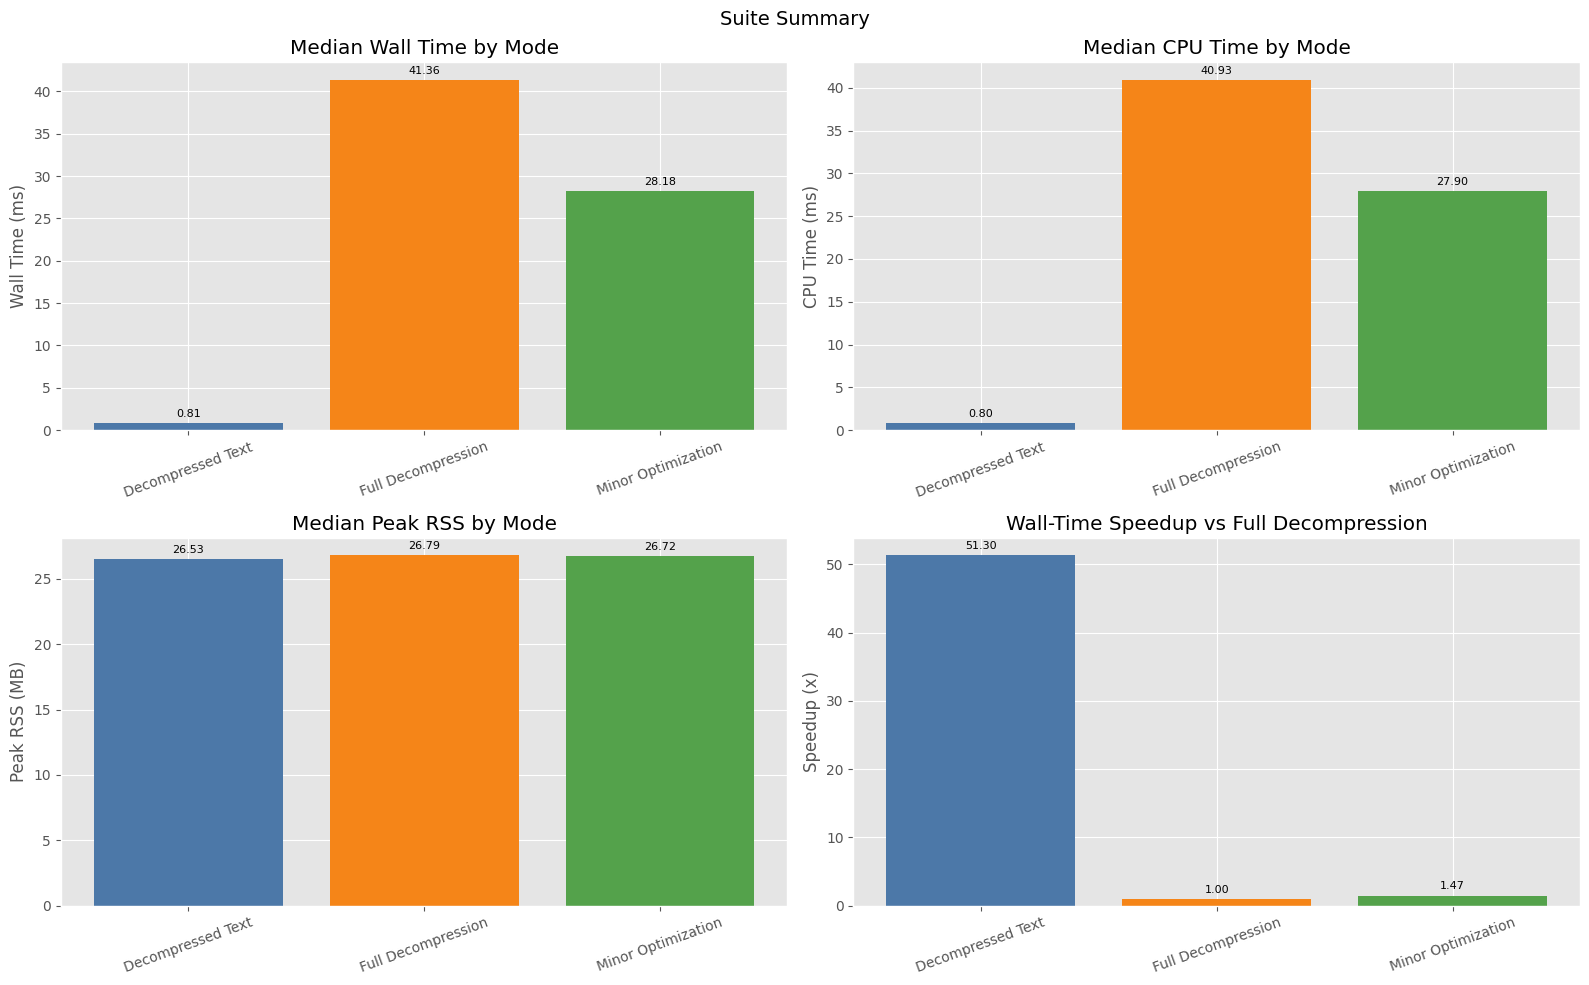

In [5]:
suite_display_df = suite_perf_df[[
    'mode_label',
    'median_wall_time_ms',
    'median_cpu_time_ms',
    'median_peak_rss_mb',
    'median_precision',
    'median_recall',
    'median_f1',
    'speedup_vs_full_decompression',
    'all_cells_exact_set_match',
]].copy()

print('Suite summary table:')
display(suite_display_df.round(4))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_columns = [
    ('median_wall_time_ms', 'Median Wall Time by Mode', 'Wall Time (ms)'),
    ('median_cpu_time_ms', 'Median CPU Time by Mode', 'CPU Time (ms)'),
    ('median_peak_rss_mb', 'Median Peak RSS by Mode', 'Peak RSS (MB)'),
    ('speedup_vs_full_decompression', 'Wall-Time Speedup vs Full Decompression', 'Speedup (x)'),
]

for ax, (column, title, ylabel) in zip(axes.flat, plot_columns):
    colors = [MODE_COLORS[mode] for mode in suite_perf_df['mode_name'].astype(str)]
    ax.bar(suite_perf_df['mode_label'], suite_perf_df[column], color=colors)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=20)
    annotate_bars(ax, fmt='{:.2f}')

fig.suptitle('Suite Summary', fontsize=14)
fig.tight_layout()
maybe_savefig(fig, results_dir, 'suite_summary')
plt.show()


## 6. Dataset and Query Breakdown

These plots help answer whether performance differences come from the mode itself,
from particular datasets, or from particular query families.


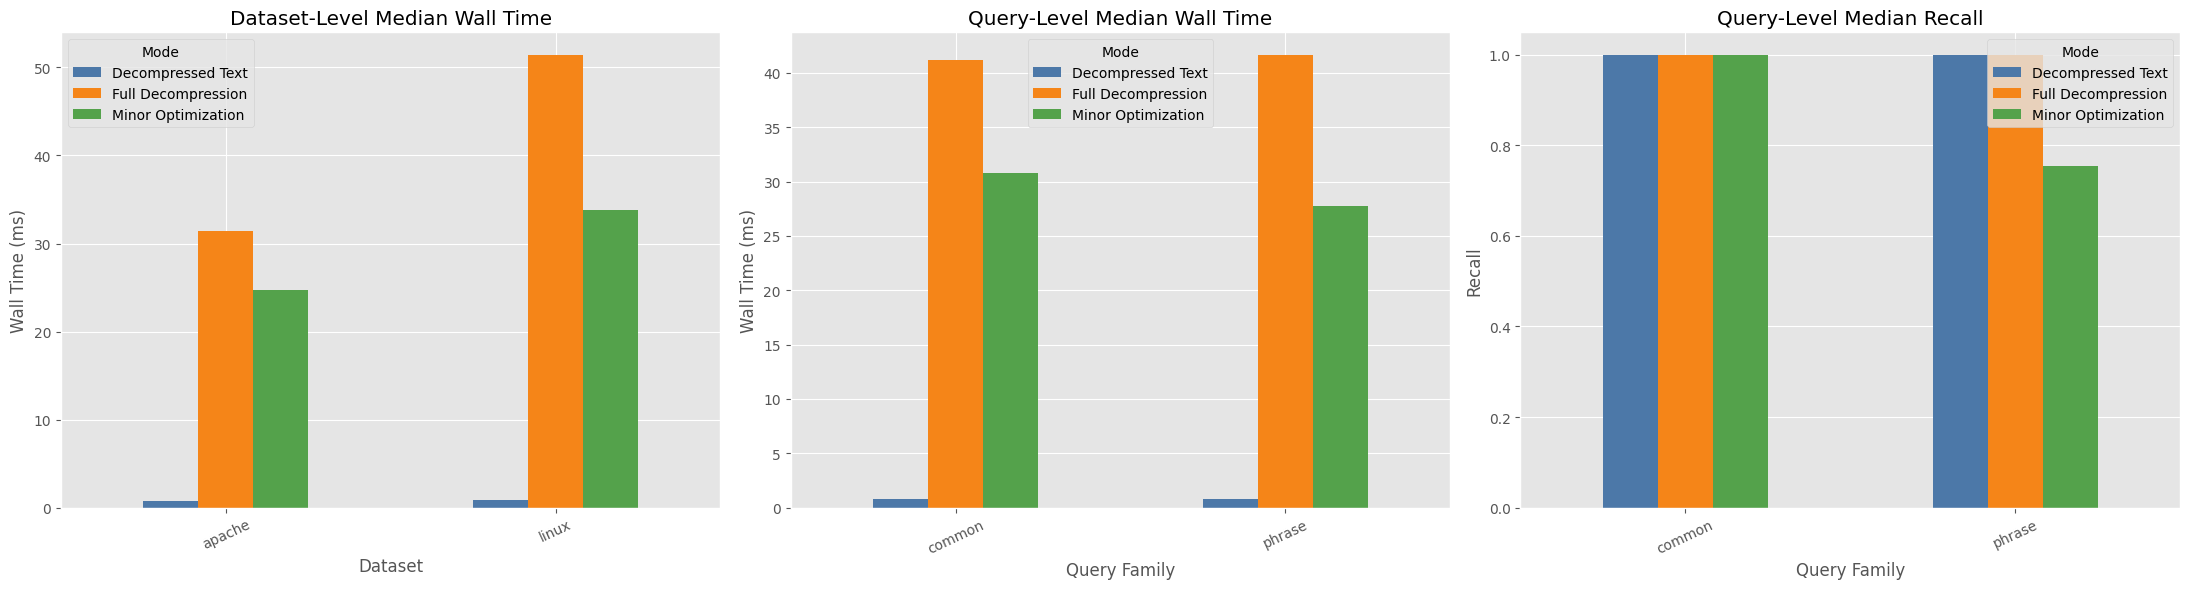

In [6]:
runtime_pivot = dataset_df.pivot(index='dataset_slug', columns='mode_name', values='median_wall_time_ms')
runtime_pivot = runtime_pivot.reindex(columns=MODE_ORDER)
runtime_pivot.columns = [MODE_LABELS[column] for column in runtime_pivot.columns]

query_runtime_pivot = query_df.pivot(index='query_id', columns='mode_name', values='median_wall_time_ms')
query_runtime_pivot = query_runtime_pivot.reindex(columns=MODE_ORDER)
query_runtime_pivot.columns = [MODE_LABELS[column] for column in query_runtime_pivot.columns]

query_recall_pivot = query_df.pivot(index='query_id', columns='mode_name', values='median_recall')
query_recall_pivot = query_recall_pivot.reindex(columns=MODE_ORDER)
query_recall_pivot.columns = [MODE_LABELS[column] for column in query_recall_pivot.columns]

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

runtime_pivot.plot(kind='bar', ax=axes[0], color=[MODE_COLORS[mode] for mode in MODE_ORDER])
axes[0].set_title('Dataset-Level Median Wall Time')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Wall Time (ms)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='Mode')

query_runtime_pivot.plot(kind='bar', ax=axes[1], color=[MODE_COLORS[mode] for mode in MODE_ORDER])
axes[1].set_title('Query-Level Median Wall Time')
axes[1].set_xlabel('Query Family')
axes[1].set_ylabel('Wall Time (ms)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Mode')

query_recall_pivot.plot(kind='bar', ax=axes[2], color=[MODE_COLORS[mode] for mode in MODE_ORDER])
axes[2].set_title('Query-Level Median Recall')
axes[2].set_xlabel('Query Family')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1.05)
axes[2].tick_params(axis='x', rotation=25)
axes[2].legend(title='Mode')

fig.tight_layout()
maybe_savefig(fig, results_dir, 'dataset_query_breakdown')
plt.show()


## 7. Correctness View for the Optimization Candidate

This section isolates `minor_optimization` because that is the experimental mode.
It shows where the optimization earns speedups and where it loses recall or F1.


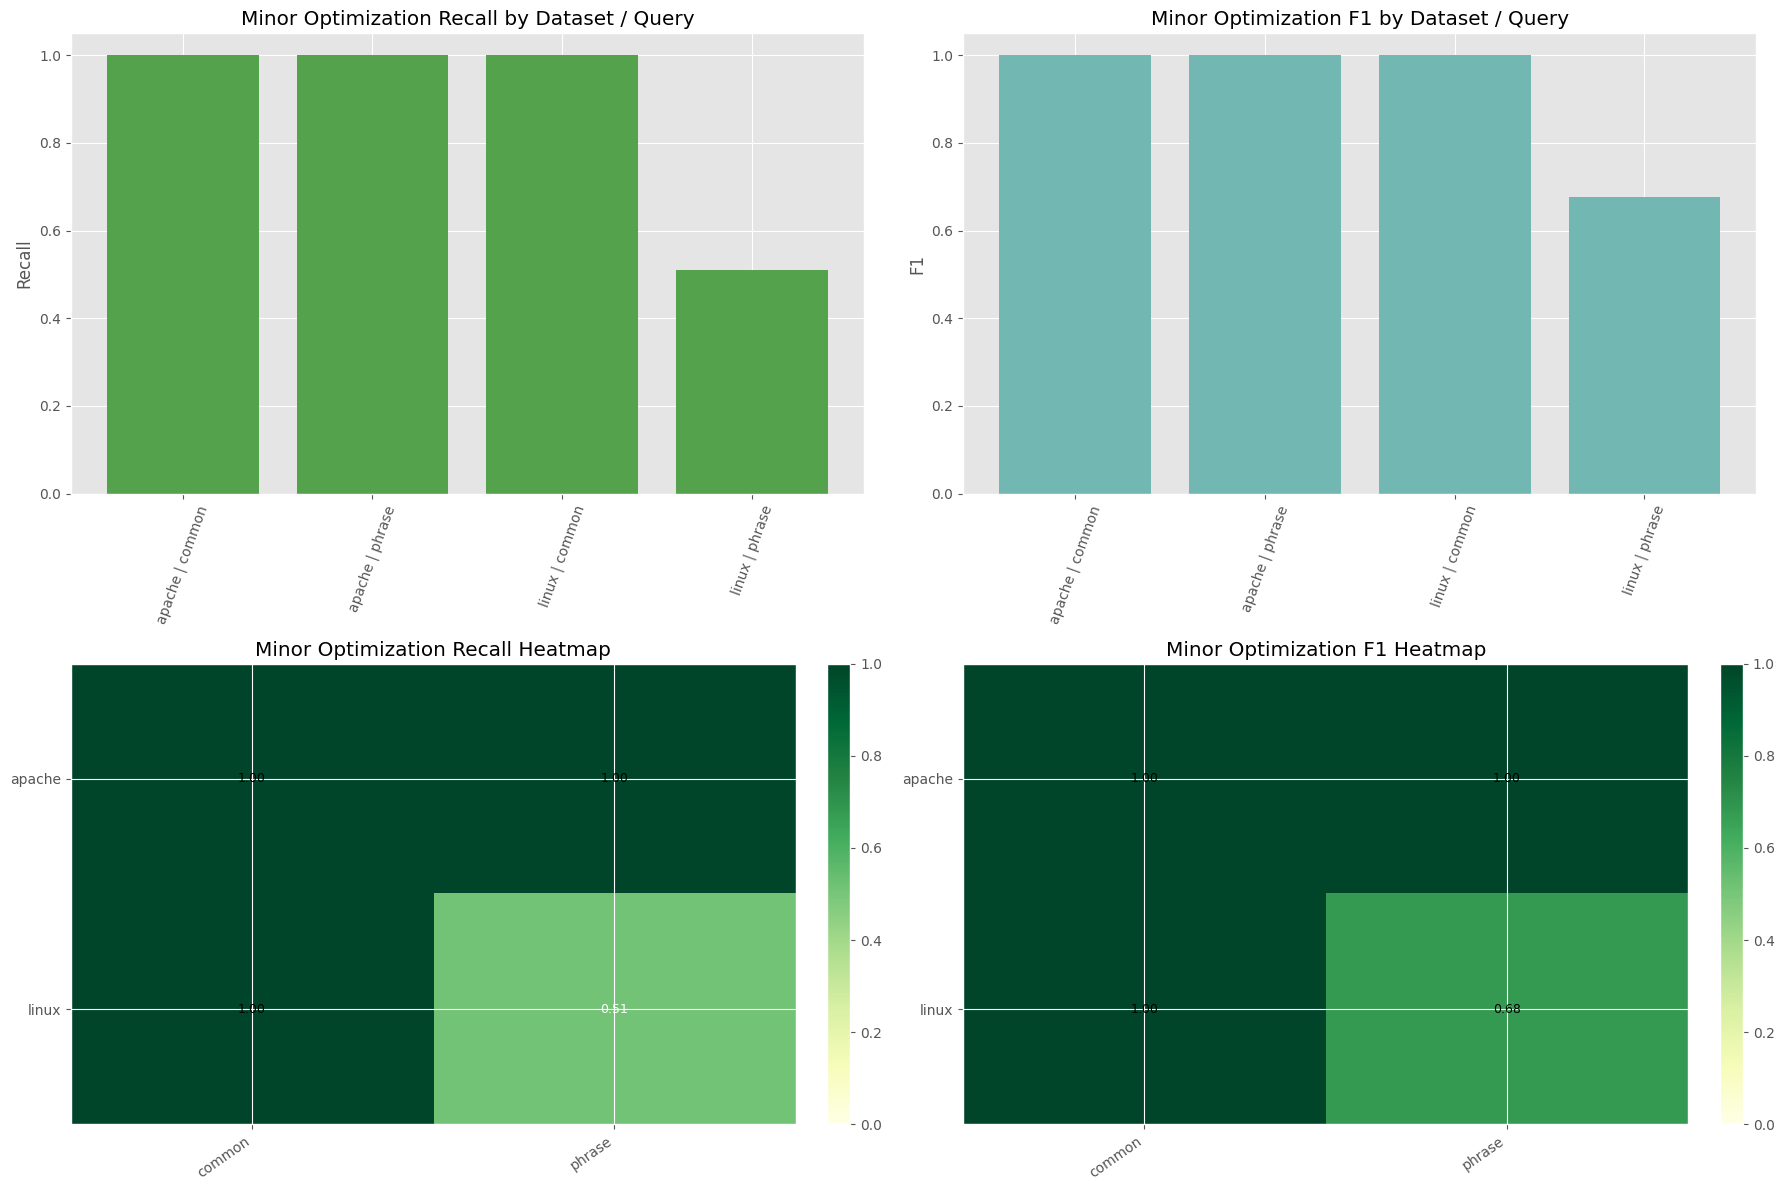

In [7]:
minor_df = cell_df.loc[cell_df['mode_name'] == 'minor_optimization'].copy()
minor_df['dataset_query'] = minor_df['dataset_slug'] + ' | ' + minor_df['query_id']
minor_df = minor_df.sort_values(by=['dataset_slug', 'query_id']).reset_index(drop=True)

minor_recall_heatmap = minor_df.pivot(index='dataset_slug', columns='query_id', values='median_recall')
minor_f1_heatmap = minor_df.pivot(index='dataset_slug', columns='query_id', values='median_f1')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

axes[0, 0].bar(minor_df['dataset_query'], minor_df['median_recall'], color=MODE_COLORS['minor_optimization'])
axes[0, 0].set_title('Minor Optimization Recall by Dataset / Query')
axes[0, 0].set_ylabel('Recall')
axes[0, 0].set_ylim(0, 1.05)
axes[0, 0].tick_params(axis='x', rotation=70)

axes[0, 1].bar(minor_df['dataset_query'], minor_df['median_f1'], color='#72B7B2')
axes[0, 1].set_title('Minor Optimization F1 by Dataset / Query')
axes[0, 1].set_ylabel('F1')
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].tick_params(axis='x', rotation=70)

recall_image = plot_heatmap(axes[1, 0], minor_recall_heatmap, 'Minor Optimization Recall Heatmap')
f1_image = plot_heatmap(axes[1, 1], minor_f1_heatmap, 'Minor Optimization F1 Heatmap')

fig.colorbar(recall_image, ax=axes[1, 0], fraction=0.046, pad=0.04)
fig.colorbar(f1_image, ax=axes[1, 1], fraction=0.046, pad=0.04)

fig.tight_layout()
maybe_savefig(fig, results_dir, 'minor_optimization_correctness')
plt.show()


## 8. Trade-Off Plot: Speedup vs Recall

This view makes the core research question easy to explain:
does `minor_optimization` save time without sacrificing too much correctness?


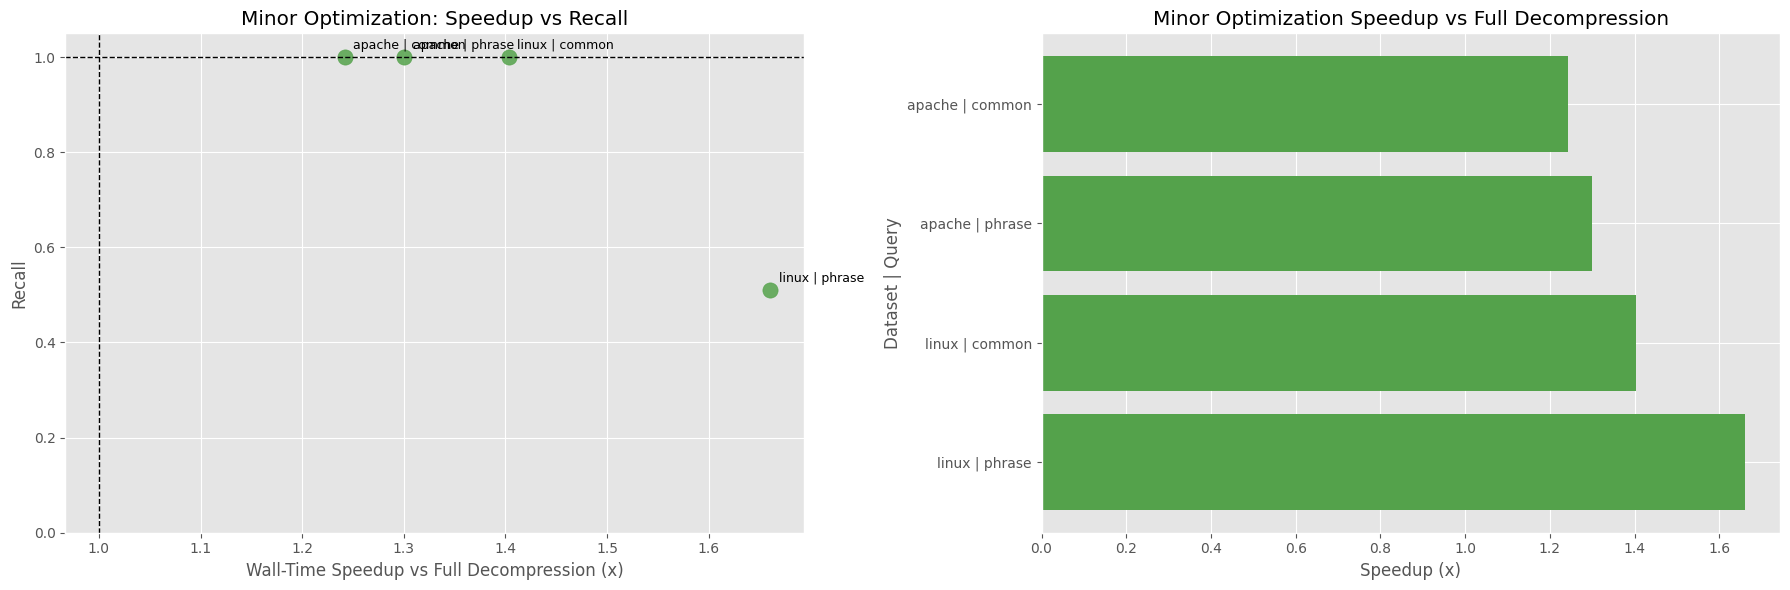

Trade-off table:


,dataset_slug,query_id,wall_time_speedup_vs_full,cpu_time_speedup_vs_full,median_recall,median_f1,median_fp,median_fn,rss_delta_vs_full_mb,all_runs_exact_set_match
3,linux,phrase,1.6604,1.6514,0.5106,0.6761,0.0,23.0,0.0000,False
2,linux,common,1.4031,1.4011,1.0000,1.0000,0.0,0.0,-0.1094,True
1,apache,phrase,1.3004,1.3043,1.0000,1.0000,0.0,0.0,-0.1406,True
0,apache,common,1.2420,1.2438,1.0000,1.0000,0.0,0.0,0.0781,True


In [8]:
tradeoff_df = minor_compare_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].scatter(
    tradeoff_df['wall_time_speedup_vs_full'],
    tradeoff_df['median_recall'],
    s=120,
    color=MODE_COLORS['minor_optimization'],
    alpha=0.85,
)
for _, row in tradeoff_df.iterrows():
    axes[0].annotate(
        row['dataset_query'],
        (row['wall_time_speedup_vs_full'], row['median_recall']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=9,
    )
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Minor Optimization: Speedup vs Recall')
axes[0].set_xlabel('Wall-Time Speedup vs Full Decompression (x)')
axes[0].set_ylabel('Recall')
axes[0].set_ylim(0, 1.05)

tradeoff_df = tradeoff_df.sort_values('wall_time_speedup_vs_full', ascending=False)
axes[1].barh(tradeoff_df['dataset_query'], tradeoff_df['wall_time_speedup_vs_full'], color=MODE_COLORS['minor_optimization'])
axes[1].set_title('Minor Optimization Speedup vs Full Decompression')
axes[1].set_xlabel('Speedup (x)')
axes[1].set_ylabel('Dataset | Query')

fig.tight_layout()
maybe_savefig(fig, results_dir, 'minor_tradeoff')
plt.show()

print('Trade-off table:')
display(
    tradeoff_df[[
        'dataset_slug',
        'query_id',
        'wall_time_speedup_vs_full',
        'cpu_time_speedup_vs_full',
        'median_recall',
        'median_f1',
        'median_fp',
        'median_fn',
        'rss_delta_vs_full_mb',
        'all_runs_exact_set_match',
    ]].round(4)
)


## 9. Raw Repetition Variability

Aggregate medians are useful, but this section also shows spread across individual measured runs.
That helps separate a real pattern from run-to-run noise.


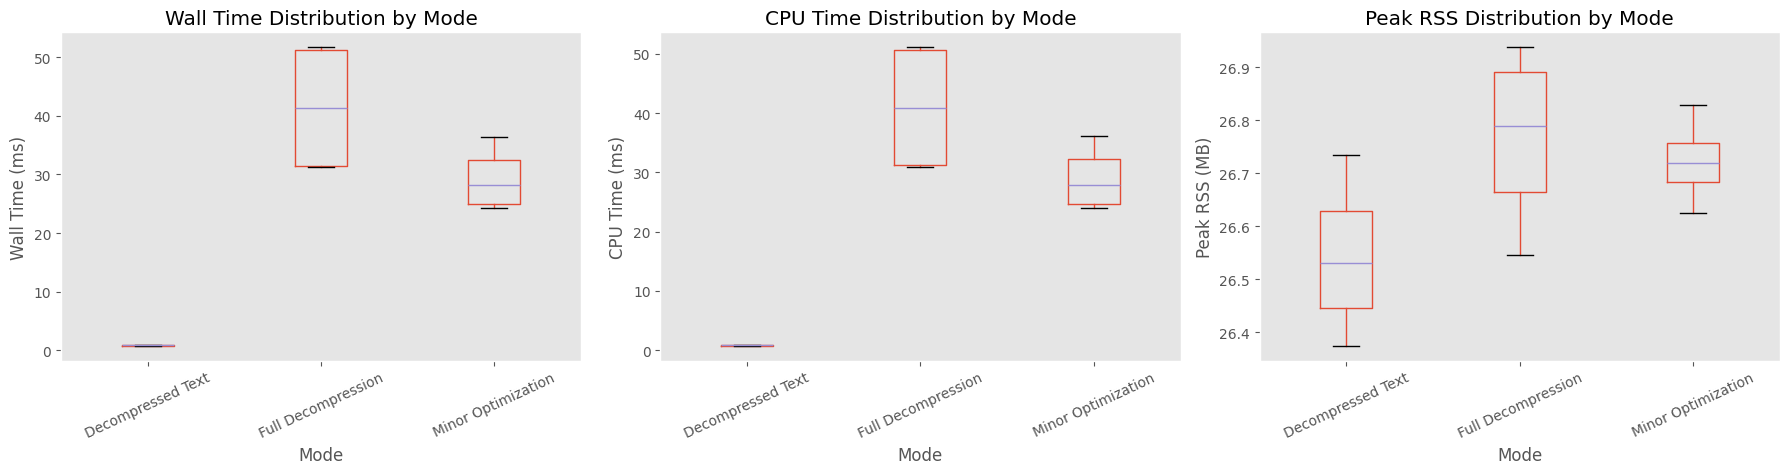

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

measured_raw_df.boxplot(column='wall_time_ms', by='mode_name', ax=axes[0], grid=False)
axes[0].set_title('Wall Time Distribution by Mode')
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Wall Time (ms)')
axes[0].set_xticklabels([MODE_LABELS[label.get_text()] for label in axes[0].get_xticklabels()], rotation=25)

measured_raw_df.boxplot(column='cpu_time_ms', by='mode_name', ax=axes[1], grid=False)
axes[1].set_title('CPU Time Distribution by Mode')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('CPU Time (ms)')
axes[1].set_xticklabels([MODE_LABELS[label.get_text()] for label in axes[1].get_xticklabels()], rotation=25)

measured_raw_df.boxplot(column='peak_rss_mb', by='mode_name', ax=axes[2], grid=False)
axes[2].set_title('Peak RSS Distribution by Mode')
axes[2].set_xlabel('Mode')
axes[2].set_ylabel('Peak RSS (MB)')
axes[2].set_xticklabels([MODE_LABELS[label.get_text()] for label in axes[2].get_xticklabels()], rotation=25)

plt.suptitle('')
fig.tight_layout()
maybe_savefig(fig, results_dir, 'repetition_variability')
plt.show()


## 10. Qualitative Error Audit

When a cell is non-exact, the raw JSONL ledger contains sampled false negatives and false positives.
This is the right place to pull examples for a report or presentation.


In [10]:
error_runs = measured_raw_df.loc[~measured_raw_df['exact_set_match']].copy()
error_runs = error_runs.sort_values(['dataset_slug', 'query_id', 'mode_name', 'repetition_index']).reset_index(drop=True)

if error_runs.empty:
    print('No non-exact measured runs were found in this results directory.')
else:
    error_audit_rows = []
    for _, row in error_runs.iterrows():
        error_audit_rows.append({
            'dataset_slug': row['dataset_slug'],
            'query_id': row['query_id'],
            'mode_name': row['mode_name'],
            'repetition_index': row['repetition_index'],
            'fp': row['fp'],
            'fn': row['fn'],
            'sample_false_negative': first_sample(row['sampled_false_negatives']),
            'sample_false_positive': first_sample(row['sampled_false_positives']),
        })
    error_audit_df = pd.DataFrame(error_audit_rows)
    display(error_audit_df)


,dataset_slug,query_id,mode_name,repetition_index,fp,fn,sample_false_negative,sample_false_positive
0,linux,phrase,minor_optimization,0,0,23,Jun 30 20:53:04 combo klogind[19268]: Kerberos authentication failed,


## 11. Presentation-Ready Final Table

This last table keeps only the fields that are usually most useful for the Week 1 part-3 writeup:
- full vs minor runtime
- speedup from the optimization
- correctness loss, if any
- whether the optimization remained exact


In [11]:
final_table = presentation_table.sort_values(['dataset_slug', 'query_id']).reset_index(drop=True)
display(final_table.round(4))

if EXPORT_FIGURES:
    output_path = results_dir / 'part3_figures' / 'final_table.csv'
    output_path.parent.mkdir(parents=True, exist_ok=True)
    final_table.to_csv(output_path, index=False)
    print(f'Saved table: {output_path}')


,dataset_slug,query_id,minor_wall_time_ms,full_wall_time_ms,wall_time_speedup_vs_full,minor_recall,minor_f1,minor_fp,minor_fn,minor_exact_match
0,apache,common,25.2078,31.3077,1.2420,1.0000,1.0000,0.0,0.0,True
1,apache,phrase,24.2848,31.5791,1.3004,1.0000,1.0000,0.0,0.0,True
2,linux,common,36.4422,51.1319,1.4031,1.0000,1.0000,0.0,0.0,True
3,linux,phrase,31.1476,51.7163,1.6604,0.5106,0.6761,0.0,23.0,False
